Les durées sont indicatives et dépendent évidemment de chaque personne.Si vous voyez que vous ne pouvez pas terminer un exercice à temps, n'hésitez pas à passer à l'exercice suivant.

Si vous n'avez pas le temps de tout terminer, vous pouvez recommencer ce week-end ou la semaine prochaine.Vous indiquerez simplement dans les commentaires les scripts que vous avez terminés par la suite.

# Partie 1 - API - Vers 1h

L'ensemble de données suivant répertorie une sélection des meilleurs restaurants de Paris, à des prix très abordables (moins de 15 euros par menu en moyenne).

In [41]:
import pandas as pd
import requests as r
from pprint import pprint
food_paris = pd.read_csv("https://raw.githubusercontent.com/WildCodeSchool/wilddata/main/food.csv").drop(columns = "Unnamed: 0")

In [42]:
food_paris.head()

,nom,adresse,code postal
0,Kodawari Tsukiji,12 Rue de Richelieu,75001 Paris
1,Café Lai’Tcha,7 Rue du Jour,75001 Paris
2,Pizz'Aria,55 Rue Montmartre,75002 Paris
3,M La Vie,85 Rue Montmartre,75002 Paris
4,Road Trip,36 Rue Poissonnière,75002 Paris


Utilisez cette [API](https://data.geopf.fr/geocodage/openapi), pour récupérer des points de coordonnées (lon, lat).

In [71]:
# Je crée une nouvelle colonne avec l'adresse + le code postal

# Fusionner l'adresse et le code postal avec un espace entre les deux
food_paris['adresse_complete'] = food_paris['adresse'].astype(str) + ", " + food_paris['code postal'].astype(str)

food_paris.head()

,nom,adresse,code postal,coordonnées,adresse_complete
0,Kodawari Tsukiji,12 Rue de Richelieu,75001 Paris,"[48.960536, 2.585988]","12 Rue de Richelieu, 75001 Paris"
1,Café Lai’Tcha,7 Rue du Jour,75001 Paris,"[48.74075, 2.303353]","7 Rue du Jour, 75001 Paris"
2,Pizz'Aria,55 Rue Montmartre,75002 Paris,"[48.865983, 2.344484]","55 Rue Montmartre, 75002 Paris"
3,M La Vie,85 Rue Montmartre,75002 Paris,"[48.867596, 2.343757]","85 Rue Montmartre, 75002 Paris"
4,Road Trip,36 Rue Poissonnière,75002 Paris,"[48.869951, 2.34794]","36 Rue Poissonnière, 75002 Paris"


In [72]:
# Je définis mon url
link = 'https://data.geopf.fr/geocodage/search?q='

def API_address(postal_address):
  url = link + postal_address.replace(" ","+")
  result = r.get(url).json()
  coord = result['features'][0]['geometry']['coordinates'][::-1]
  return coord

print("Je récupère les coordonnées de Kodawari Tsukiji au 12 rue de Richelieu:")
API_address("12 Rue de Richelieu")

Je récupère les coordonnées de Kodawari Tsukiji au 12 rue de Richelieu:


[48.960536, 2.585988]

In [73]:
food_paris['coordonnées'] = food_paris['adresse_complete'].apply(API_address)
display(food_paris)

,nom,adresse,code postal,coordonnées,adresse_complete
0,Kodawari Tsukiji,12 Rue de Richelieu,75001 Paris,"[48.864374, 2.336258]","12 Rue de Richelieu, 75001 Paris"
1,Café Lai’Tcha,7 Rue du Jour,75001 Paris,"[48.86355, 2.344247]","7 Rue du Jour, 75001 Paris"
2,Pizz'Aria,55 Rue Montmartre,75002 Paris,"[48.865983, 2.344484]","55 Rue Montmartre, 75002 Paris"
3,M La Vie,85 Rue Montmartre,75002 Paris,"[48.867596, 2.343757]","85 Rue Montmartre, 75002 Paris"
4,Road Trip,36 Rue Poissonnière,75002 Paris,"[48.869951, 2.34794]","36 Rue Poissonnière, 75002 Paris"
5,Rolls,29 Rue des Jeuneurs,75002 Paris,"[48.869541, 2.344421]","29 Rue des Jeuneurs, 75002 Paris"
6,Qasti Shawarma,214 Rue Saint-Martin,75003 Paris,"[48.863752, 2.35287]","214 Rue Saint-Martin, 75003 Paris"
7,The Brooklyn Pizzeria,33 Bd Beaumarchais,75003 Paris,"[48.856, 2.368186]","33 Bd Beaumarchais, 75003 Paris"
8,La Baguette du relais,10 Rue des Archives,75004 Paris,"[48.857587, 2.354532]","10 Rue des Archives, 75004 Paris"
9,Olive & Thym,60 Rue Quincampoix,75004 Paris,"[48.861576, 2.35082]","60 Rue Quincampoix, 75004 Paris"


Mettez ces coordonnées dans une colonnes dans votre DataFrame `food_paris`

# Folium

Affichez maintenant ces restaurants sur une carte, en utilisant la bibliothèque `folium`.

In [74]:
import folium

# Je crée ma carte basée sur Kodawari Tsukiji
m = folium.Map(location=food_paris['coordonnées'][9], zoom_start=11)

# j'ajoute tous les marqueurs sur la même carte avec ma boucle
for i in range(len(food_paris)):
    coord = food_paris['coordonnées'][i]
    folium.Marker(
        location=coord,
        popup= food_paris['nom'][i]
    ).add_to(m)

m  # j'affiche la carte



# Tri et regroupement

Afficher un classement descendant, compte tenu du nombre de restaurants par code postal.

In [75]:
# J'affiche un classement regroupant le nombre de restaurant par code postal du plus grand au plus petit grace à value_counts()

food_paris.value_counts("code postal")

code postal
75002 Paris    5
75009 Paris    4
75010 Paris    4
75011 Paris    3
75001 Paris    2
75003 Paris    2
75004 Paris    2
75006 Paris    2
75008 Paris    2
75007 Paris    1
75014 Paris    1
75017 Paris    1
Name: count, dtype: int64

# Partie 2 - Exploration et traitement des données - Python & Pandas - environ 30 min

Exécutez le code ci-dessous.Vous obtiendrez un DataFrame avec 10 000 commentaires de restaurant.
- Date: la date du commentaire
- Stars: La note (de 1 à 5)
- Texte: le texte du commentaire
- Useful: le nombre d'utilisateurs qui ont indiqué ce commentaire comme "utile"
- Sentiment: le mot "bon" ou "mauvais" selon la note des étoiles

L'objectif de ces pièces sera d'explorer cet ensemble de données, puis de proposer un modèle de prédiction de notation positive selon les autres fonctionnalités.

Commencez par vérifier qu'il n'y a pas de valeurs manquantes.

In [11]:
import pandas as pd
df_restaurants = pd.read_csv("https://github.com/WildCodeSchool/wilddata/raw/main/restaurant.zip", index_col='Unnamed: 0').loc[:,["date", "stars", "text", "useful"]]
df_restaurants["sentiment"] = df_restaurants["stars"].apply(lambda x: "bad" if x <=3 else "good")
df_restaurants

,date,stars,text,useful,sentiment
0,2011-01-26,5,My wife took me here on my birthday for breakf...,5,good
1,2011-07-27,5,I have no idea why some people give bad review...,0,good
2,2012-06-14,4,love the gyro plate. Rice is so good and I als...,1,good
3,2010-05-27,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",2,good
4,2012-01-05,5,General Manager Scott Petello is a good egg!!!...,0,good
...,...,...,...,...,...
9995,2012-07-28,3,First visit...Had lunch here today - used my G...,2,bad
9996,2012-01-18,4,Should be called house of deliciousness!\n\nI ...,0,good
9997,2010-11-16,4,I recently visited Olive and Ivy for business ...,0,good
9998,2012-12-02,2,My nephew just moved to Scottsdale recently so...,0,bad


In [12]:
# Je verifie les valeurs manquantes
df_restaurants.isna().sum()

date         0
stars        0
text         0
useful       0
sentiment    0
dtype: int64

## colonne "texte"

Utilisez **Apply** pour créer une nouvelle colonne `len_text`, indiquant la longueur (nombre de caractères) de chaque commentaire.

Afficher un histogramme et un `boxplot` pour représenter la distribution de cette colonne `len_text`.Les valeurs sont-elles bien distribuées?La plupart des commentaires sont-ils longs ou courts?

REPONSE : Les valeurs ne sont pas bien distribuées, il y a enorméménet d'outliers (valeurs aberrantes), 75% des commentaires font moins de 100 caractères et il y a plein de commentaires isolés qui sont plus longs, certainement les clients qui laissent des avis pour se plaindre ou raconter ce qui ne va pas (ou bien ce qui va) de manière détaillée sur le restaurant en question.

In [13]:
# Je compte les caractère grace a une fonction lambda dans mon apply
df_restaurants['len_text'] = df_restaurants['text'].apply(lambda x : len(x))
display(df_restaurants.head()) # Je vérifie la cohérence


,date,stars,text,useful,sentiment,len_text
0,2011-01-26,5,My wife took me here on my birthday for breakf...,5,good,889
1,2011-07-27,5,I have no idea why some people give bad review...,0,good,1345
2,2012-06-14,4,love the gyro plate. Rice is so good and I als...,1,good,76
3,2010-05-27,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",2,good,419
4,2012-01-05,5,General Manager Scott Petello is a good egg!!!...,0,good,469


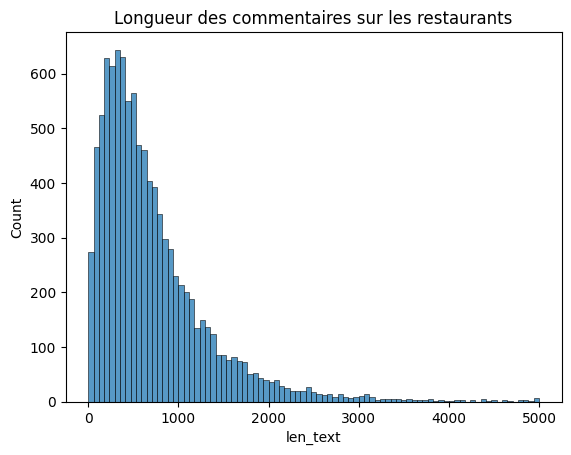

In [14]:
# J'importe mes bibliotheques
import seaborn as sns
import matplotlib.pyplot as plt

# Afficher un histogramme
# sns_histplot : Histogramme avec densité
sns.histplot(data=df_restaurants, x='len_text')
plt.title('Longueur des commentaires sur les restaurants')
plt.show()

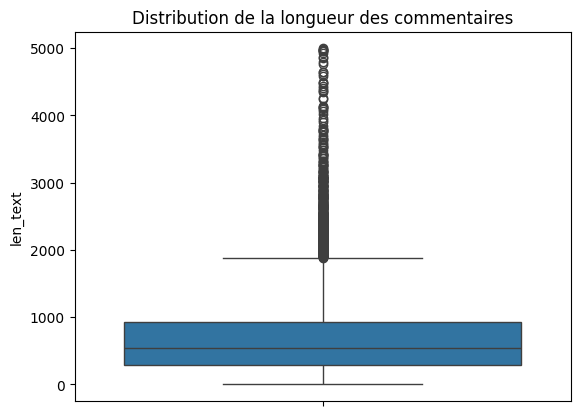

In [15]:
# Afficher un boxplot
# sns_boxplot : Visualise la distribution + outliers
sns.boxplot(data=df_restaurants, y='len_text')
plt.title('Distribution de la longueur des commentaires')
plt.show()

## Colonne "Stars"

- Afficher un diagramme de dispersion pour comparer la colonne `utile` et la colonne `stars`.Pensez-vous qu'il y a une corrélation?Veuillez calculer le coefficient de corrélation.

- Idem entre `len_text` et `useful`.

- Veuillez commenter et interpréter les résultats.

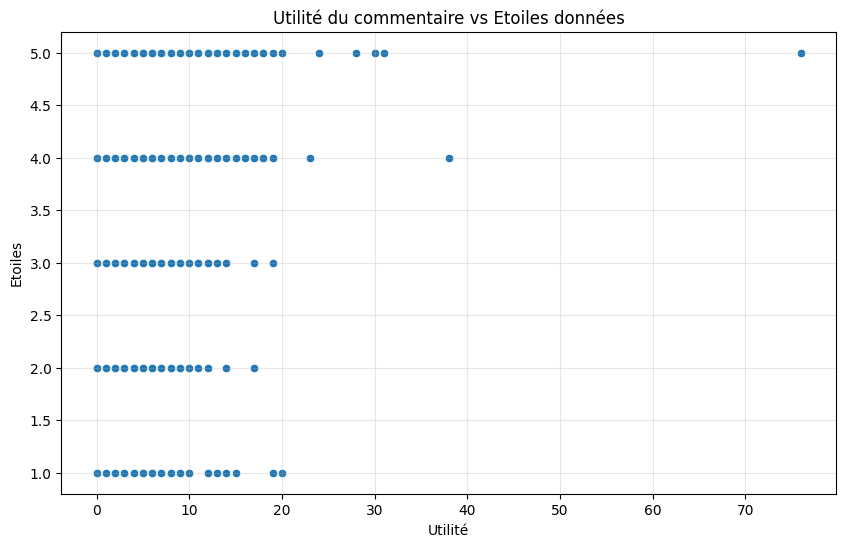

In [17]:
# Afficher un scatterplot pour la dispersion entre useful et stars
# Scatter simple et fiable avec Matplotlib + Seaborn
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_restaurants, 
 x='useful', 
 y='stars', )

plt.title('Utilité du commentaire vs Etoiles données')
plt.xlabel('Utilité')
plt.ylabel('Etoiles')
plt.grid(True, alpha=0.3)
plt.show()


Il n'y a vraisemblablement pas de correlation, on remarque que dans toutes les notes données il y a des commentaires jugées utiles et non utiles, cela n'a pas de lien avec la note.

In [18]:
# On calcule le coefficient de correlation

print(f"Le coefficient de correlation est {df_restaurants['useful'].corr(df_restaurants['stars']).round(2)}, il n'y a donc pas de correlation")

Le coefficient de correlation est -0.02, il n'y a donc pas de correlation


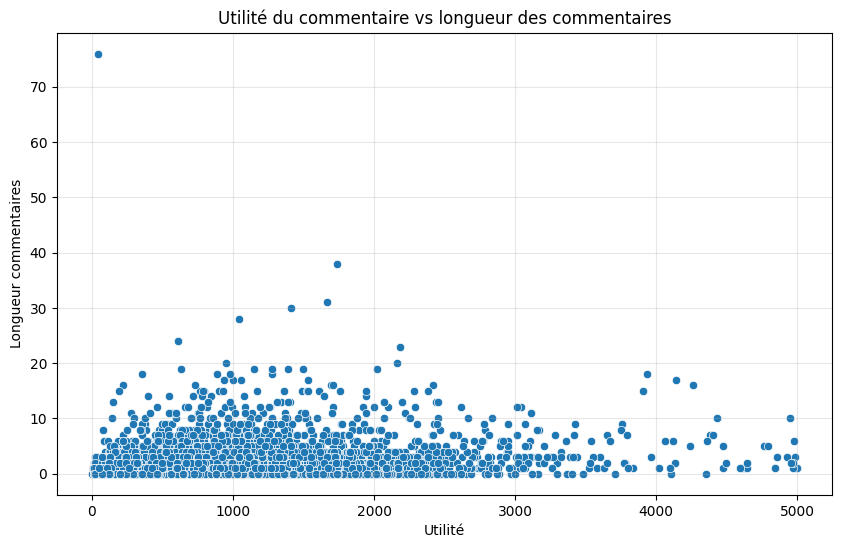

In [19]:
# Afficher un scatterplot pour la dispersion entre len_text et useful
# Scatter simple et fiable avec Matplotlib + Seaborn
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_restaurants, 
 x='len_text', 
 y='useful', )

plt.title('Utilité du commentaire vs longueur des commentaires')
plt.xlabel('Utilité')
plt.ylabel('Longueur commentaires')
plt.grid(True, alpha=0.3)
plt.show()

Ici, il semble qu'il y ait une correlation, mais légère. Verifions avec le coefficient de correlation

In [20]:
# On calcule le coefficient de correlation

print(f"Le coefficient de correlation est {df_restaurants['useful'].corr(df_restaurants['len_text']).round(2)}, il y a une corelation légère et modérée")

Le coefficient de correlation est 0.29, il y a une corelation légère et modérée


INTERPRETATION : Ici, la correlation est légère et modérée. Pour la relation entre les commentaires jugés utiles et les etoiles données par les clients, il n'y avait pas de correlation. On peut très bien juger un commentaire utile pour une note mauvaise ou bien pour une bonne note. Pour l'autre relation entre les commentaires jugés utiles et la longueur des commentaires, on peut estimer que la légère correlation est du au fait qu'un commentaire peut etre jugé utile lorsqu'il contient du texte, donc lorsqu'il a un minimum de caractère. Mais ce n'est pas le seul critère, il faut que le contenu soit pertient.

# Partie 3: NLP - Classification d'analyse des sentiments - 2h

Définissez `X` qui ne contiendra que la colonne `text`et `y` qui sera la colonne `sentiment`.

In [21]:
X = df_restaurants['text']
y = df_restaurants['sentiment']

## Créez une fonction pour nettoyer les mots d'arrêt et la ponctuation

Vous pouvez appeler votre fonction `func_clean`.
Votre fonction doit prendre un `str` en tant que paramètre unique et retourner un `str`.

Par exemple:

`func_clean("Hello, how are you? Fine, thank you.")`

`>>> 'hello fine thank'`

In [22]:
# J'importe spacy et regex 
import spacy
import regex as re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


# Je crée ma variable qui contient la langue anglaise car mes commentaires sont en anglais
nlp = spacy.load("en_core_web_sm")

In [77]:
def func_clean(text):
    text = text.lower()     # Minuscule
    doc = nlp(text)          # Analyse par spaCy
    clean_tokens = [t.lemma_ for t in doc if not t.is_stop and not t.is_punct and not t.is_space]
                               # Filtrage : on garde le lemme (forme canonique) si ce n'est pas un stopword, ni de la ponctuation, ni un espace
    return " ".join(clean_tokens)    # Fusion de la liste en une chaîne de texte

In [78]:
# J'essaye ma fonction 
func_clean("Hello, how are you? Fine, thank you.")

'hello fine thank'

## Appliquer cette fonction

Apply cette fonction à `X` et stockez le résultat dans la variable ` X_clean`.

In [25]:
X_clean = X.apply(func_clean)

In [26]:
X_clean

0       wife take birthday breakfast excellent   weath...
1       idea people bad review place go probably grip ...
2           love gyro plate rice good dig candy selection
3       rosie dakota love chaparral dog park convenien...
4       general manager scott petello good egg detail ...
                              ...                        
9995    visithad lunch today   groupon  \n\n order bru...
9996    call house deliciousness \n\n item item blah b...
9997    recently visit olive ivy business week   visit...
9998    nephew move scottsdale recently bunch friend b...
9999      location   star average think arizona fantas...
Name: text, Length: 10000, dtype: str

## Split de test de train

Divisez vos données `X_clean` et `y` avec un `train_test_split()`, et le même `random_state = 32`.

In [27]:
X_clean_train, X_clean_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=32)

## tfidfvectorizer

- Initialiser votre vectorisateur et stockez le résultat dans `vectorizer`
- Train `vectorizer` sur ` x_train`.
- Train et Transform `x_train` avec votre vectorisateur et stockez le résultat dans `x_train_vecto`.
- Transformez `x_test` avec votre vectorisateur et stockez le résultat dans` x_test_vecto`.

In [28]:
# J'initialise mon vectorisateur
vectorizer = TfidfVectorizer()

# J'entraine et transforme 
X_train_vecto = vectorizer.fit_transform(X_clean_train)
# Je transforme uniquement sur le test
X_test_vecto = vectorizer.transform(X_clean_test)

## Régression logistique

Entrainer un modèle de régression logistique sur `x_train_vecto` et` y_train`.

Veuillez comparer les scores de précision des ensembles de formation et de test.Y a-t-il un sur-ajustement (`OverFitting)`?

Affichez également une matrice de confusion pour l'ensemble de tests.Combien de «mauvais» commentaires sont correctement prédits?

In [29]:
# J'instancie mon modele 
model = LogisticRegression()

# J'entraine le modele sur x_train_vecto et y_train
model.fit(X_train_vecto, y_train)

LogisticRegression()

In [30]:
# Je fais mes predictions
y_test_pred = model.predict(X_test_vecto)
y_train_pred = model.predict(X_train_vecto)

Accuracy Train : 0.88525
Accuracy Test : 0.8255
              precision    recall  f1-score   support

         bad       0.81      0.56      0.66       610
        good       0.83      0.94      0.88      1390

    accuracy                           0.83      2000
   macro avg       0.82      0.75      0.77      2000
weighted avg       0.82      0.83      0.81      2000



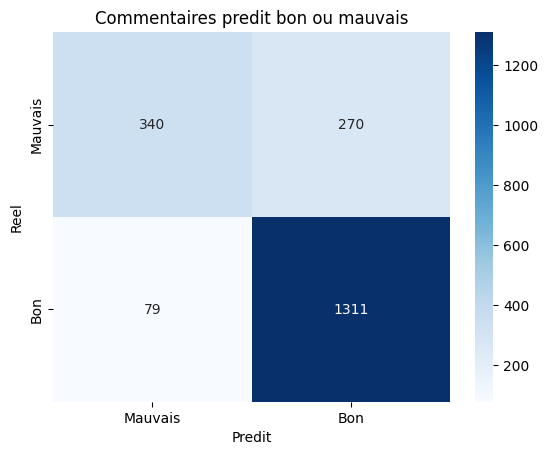

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

print(f"Accuracy Train : {accuracy_score(y_train, y_train_pred)}")
print(f"Accuracy Test : {accuracy_score(y_test, y_test_pred)}")

#J'affiche mon rapport de classification
print(classification_report(y_test, y_test_pred))

# J'affiche une matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)
def matrice_confusion(y_test, y_pred, labels=None):
    """
    Afficher la matrice de confusion
    Avec labels : matrice_confusion(y_test, y_pred, labels=['Bon', 'Mauvais'])
    """
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predit')
    plt.ylabel('Reel')
    plt.title('Commentaires predit bon ou mauvais')
    plt.show()

matrice_confusion(y_test, y_test_pred, labels=['Mauvais', 'Bon'])

Il y a un léger overfitting, le modèle a un peu trop appris sur le train avec 0.06 d'ecart en calculant l'accuracy avec 0.88 sur le train et 0.82 sur le test.

On voit que le modèle a 81% de precision sur les bad et 83% sur les mauvais.

Sur le recall et le f1 score, le modele est meilleur sur les bons commentaires, il en a aussi plus a disposition 1390 contre 610.

Sur la matrice de confusion, on voit que 340 commentaires sont correctement prédits.



## Arbre de décision
Entrainer un modèle d'arbre de décision sur `x_train_vecto` et` y_train`.

Veuillez comparer les scores de précision des ensembles de formation et de test.Y a-t-il un sur-ajustement?Les scores sont-ils meilleurs qu'auparavant?

In [32]:
# J'instancie mon modele 
model = DecisionTreeClassifier()

# J'entraine le modele sur x_train_vecto et y_train
model.fit(X_train_vecto, y_train)

DecisionTreeClassifier()

In [33]:
# Je fais mes predictions
y_test_pred = model.predict(X_test_vecto)
y_train_pred = model.predict(X_train_vecto)

Accuracy Train : 1.0
Accuracy Test : 0.7145
              precision    recall  f1-score   support

         bad       0.53      0.58      0.55       610
        good       0.81      0.77      0.79      1390

    accuracy                           0.71      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.72      0.71      0.72      2000



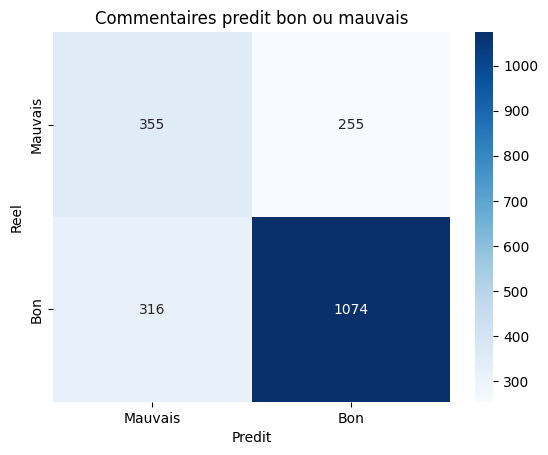

In [34]:
print(f"Accuracy Train : {accuracy_score(y_train, y_train_pred)}")
print(f"Accuracy Test : {accuracy_score(y_test, y_test_pred)}")

#J'affiche mon rapport de classification
print(classification_report(y_test, y_test_pred))

# J'affiche une matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)
def matrice_confusion(y_test, y_pred, labels=None):
    """
    Afficher la matrice de confusion
    Avec labels : matrice_confusion(y_test, y_pred, labels=['Bon', 'Mauvais'])
    """
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predit')
    plt.ylabel('Reel')
    plt.title('Commentaires predit bon ou mauvais')
    plt.show()

matrice_confusion(y_test, y_test_pred, labels=['Mauvais', 'Bon'])

## Comparaison des algorithmes

Comparer les scores des 2 algorithmes, intéprétez et dites-nous lequel est meilleur selon vous ?

Avec l'arbre de decision il y a un overfitting car les données d'entrainement sont a 1.0 et les données de test sont a 0.7, il y a 0.3 d'ecart ce qui est enorme.

Pour la regression logistique, les données de train (0.88) et de test (0.82) sont très proches donc le modèle fonctionne bien et il est plus efficace.

Cela veut dire que le modèle apprend trop bien, ce modèle est moins bon que le précédent.

# Optionnel: algorithme `json` et manipulation.
Il s'agit d'un fichier JSON contenant plusieurs clés.
Chaque clé a une valeur, qui pourrait potentiellement être une autre clé, contenant une autre valeur, qui pourrait potentiellement être une autre clé, etc.

In [35]:
food = {
  "clé1": {
    "fruit1": "pomme",
    "légume4": "brocoli"
  },
  "clé2": {
    "légume1": "carotte",
    "fruit5": "banane",
    "légume3": "courgette"
  },
  "clé3": {
    "niveau1": {
      "niveau2": {
        "fruit3": "orange",
        "légume5": "aubergine",
        "fruit5": "mangue"
      }
    }
  },
  "clé4": {
    "niveau1": {
      "niveau2": {
        "niveau3": {
          "fruit6": "raisin",
          "fruit7": "fraise",
          "légume4": "poivron",
          "fruit2": "pastèque"
        }
      }
    }
  }
}


Problème:
Les fruits et légumes ont été égarés dans ce fichier JSON.L'objectif est de récupérer chacun des fruits et légumes et de les attribuer à deux listes correspondantes: `Fruits_list` &` LEGETALS_LIST`.

Solution attendue:

`fruits_list` = `['pomme', 'banane', 'orange', 'mangue', 'raisin', 'fraise', 'pastèque']`

`vegetables_list` = `['brocoli', 'carotte', 'courgette', 'aubergine', 'poivron']`


In [36]:
fruits_list = []
vegetables_list = []

for cle in food:
    for sous_cle in food[cle]:
        if 'fruit' in sous_cle:
            fruits_list.append(food[cle][sous_cle])
print(f"fruits_list = {fruits_list}")


for cle in food:
    for sous_cle in food[cle]:
        if 'légume' in sous_cle:
            vegetables_list.append(food[cle][sous_cle])
print(f"vegetables_list = {vegetables_list}")

fruits_list = ['pomme', 'banane']
vegetables_list = ['brocoli', 'carotte', 'courgette']


In [37]:
fruits_list = ['pomme', 'banane', 'orange', 'mangue', 'raisin', 'fraise', 'pastèque']
vegetables_list = ['brocoli', 'carotte', 'courgette', 'aubergine', 'poivron']

Ensuite, vous créerai un nouveau dictionnaire, qui contiendra simplement deux clés: «fruits» et «légumes».Chaque clé aura la valeur de la liste des fruits et la liste des légumes.De cette façon, tout sera en ordre.

Solution attendue:

`food_dict` = `{'fruits': ['pomme','banane','orange','mangue','raisin','fraise','pastèque'],
 'legumes': ['brocoli', 'carotte', 'courgette', 'aubergine', 'poivron']}`